#  Primetrade.ai – Data Science Intern Assignment
## Trader Performance vs Market Sentiment (Fear/Greed)
---
**Datasets:**
- `fear_greed_index.csv` – 2,644 rows of daily Bitcoin Fear/Greed classifications
- `historical_data.csv` – 211,224 rows of Hyperliquid trader transactions

**Objective:** Uncover how market sentiment (Fear vs Greed) relates to trader behavior and performance.


## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

PALETTE = {
    'Extreme Fear': '#d62728', 'Fear': '#ff7f0e', 'Neutral': '#7f7f7f',
    'Greed': '#2ca02c', 'Extreme Greed': '#1f77b4',
}
SENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENT_COLORS = [PALETTE[s] for s in SENT_ORDER]
print("✅ Setup complete")


✅ Setup complete


---
## Part A — Data Preparation
### A1. Load Datasets

In [2]:
fg_raw = pd.read_csv('fear_greed_index.csv')
tr_raw = pd.read_csv('historical_data.csv')

print(f"Fear/Greed  → {fg_raw.shape[0]:,} rows × {fg_raw.shape[1]} cols")
print(f"Trader Data → {tr_raw.shape[0]:,} rows × {tr_raw.shape[1]} cols")
print()
print("=== Fear/Greed Columns ===")
print(fg_raw.dtypes)
print()
print("=== Trader Data Columns ===")
print(tr_raw.dtypes)


Fear/Greed  → 2,644 rows × 4 cols
Trader Data → 211,224 rows × 16 cols

=== Fear/Greed Columns ===
timestamp          int64
value              int64
classification    object
date              object
dtype: object

=== Trader Data Columns ===
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [3]:
fg_raw.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
tr_raw.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### A2. Missing Values & Duplicates

In [5]:
print("Fear/Greed – Missing values:")
print(fg_raw.isnull().sum())
print(f"Duplicates: {fg_raw.duplicated().sum()}")
print()
print("Trader Data – Missing values:")
print(tr_raw.isnull().sum())
print(f"Duplicates: {tr_raw.duplicated().sum()}")


Fear/Greed – Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0

Trader Data – Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0


### A3. Clean & Parse Dates

In [6]:
# Fear/Greed
fg = fg_raw.copy()
fg['date'] = pd.to_datetime(fg['date'])
fg = fg.sort_values('date').drop_duplicates('date').reset_index(drop=True)
fg['sentiment_binary'] = fg['classification'].map(
    lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral'))

print(f"FG date range: {fg['date'].min().date()} → {fg['date'].max().date()}")
# print(fg['classification'].value_counts())
print(fg['sentiment_binary'].value_counts())


FG date range: 2018-02-01 → 2025-05-02
sentiment_binary
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64


In [7]:
# Trader Data
tr = tr_raw.copy()
tr['datetime'] = pd.to_datetime(tr['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
tr['date'] = pd.to_datetime(tr['datetime'].dt.date)

tr['Closed PnL'] = pd.to_numeric(tr['Closed PnL'], errors='coerce').fillna(0)
tr['Size USD']   = pd.to_numeric(tr['Size USD'], errors='coerce').fillna(0)
tr['Fee']        = pd.to_numeric(tr['Fee'], errors='coerce').fillna(0)
tr['Net PnL']    = tr['Closed PnL'] - tr['Fee']

tr['is_long']  = tr['Direction'].isin(['Open Long','Buy','Long > Short','Close Short'])
tr['is_short'] = tr['Direction'].isin(['Open Short','Sell','Short > Long','Close Long'])
tr['is_win']   = (tr['Closed PnL'] > 0)

print(f"TR date range: {tr['date'].min().date()} → {tr['date'].max().date()}")
print(f"Unique accounts: {tr['Account'].nunique()}")
print(f"Unique coins: {tr['Coin'].nunique()}")


TR date range: 2023-05-01 → 2025-05-01
Unique accounts: 32
Unique coins: 246


### A4. Feature Engineering & Merge

In [8]:
# Daily aggregation per trader
daily = tr.groupby(['Account','date']).agg(
    total_pnl      = ('Closed PnL', 'sum'),
    net_pnl        = ('Net PnL', 'sum'),
    num_trades     = ('Trade ID', 'count'),
    avg_size_usd   = ('Size USD', 'mean'),
    total_size_usd = ('Size USD', 'sum'),
    total_fee      = ('Fee', 'sum'),
    wins           = ('is_win', 'sum'),
    longs          = ('is_long', 'sum'),
    shorts         = ('is_short', 'sum'),
).reset_index()

daily['win_rate']     = daily['wins'] / daily['num_trades'].clip(lower=1)
daily['long_short_r'] = daily['longs'] / (daily['shorts'] + 1e-9)

# Leverage proxy (relative size vs trader's own median)
trader_median = daily.groupby('Account')['total_size_usd'].transform('median').clip(lower=1)
daily['leverage_proxy'] = daily['total_size_usd'] / trader_median

# Merge with sentiment
merged = daily.merge(fg[['date','value','classification','sentiment_binary']], on='date', how='inner')

print(f"Merged shape: {merged.shape}")
print(f"Days covered: {merged['date'].nunique()}")
merged.head()


Merged shape: (2340, 17)
Days covered: 479


,Account,date,total_pnl,net_pnl,num_trades,avg_size_usd,total_size_usd,total_fee,wins,longs,shorts,win_rate,long_short_r,leverage_proxy,value,classification,sentiment_binary
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,-167.796055,177,5089.718249,900880.13,167.796055,0,0,177,0.000000,0.000000e+00,0.712412,76,Extreme Greed,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,-67.883615,68,7976.664412,542413.18,67.883615,0,0,68,0.000000,0.000000e+00,0.428938,90,Extreme Greed,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,-94.937983,40,23734.500000,949380.00,94.937983,0,0,40,0.000000,0.000000e+00,0.750765,83,Extreme Greed,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,-21260.823995,12,28186.666667,338240.00,33.823995,0,12,0,0.000000,1.200000e+10,0.267479,94,Extreme Greed,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,1498.477510,27,17248.148148,465700.00,104.622490,12,12,15,0.444444,8.000000e-01,0.368273,79,Extreme Greed,Greed


---
## Part B — Analysis
### B1. Performance by Sentiment (PnL, Win Rate)

In [21]:
perf = merged.groupby('classification').agg(
    avg_pnl      = ('total_pnl', 'mean'),
    median_pnl   = ('total_pnl', 'median'),
    avg_win_rate = ('win_rate', 'mean'),
    n_obs        = ('total_pnl', 'count'),
).reindex(SENT_ORDER).reset_index()
print(perf.to_string(index=False))


classification     avg_pnl  median_pnl  avg_win_rate  n_obs
  Extreme Fear 4619.439053  218.377399      0.329659    160
          Fear 5328.818161  107.892532      0.364033    630
       Neutral 3438.618818  167.551743      0.355414    376
         Greed 3318.100730  158.214922      0.343559    648
 Extreme Greed 5161.922644  418.319862      0.386387    526


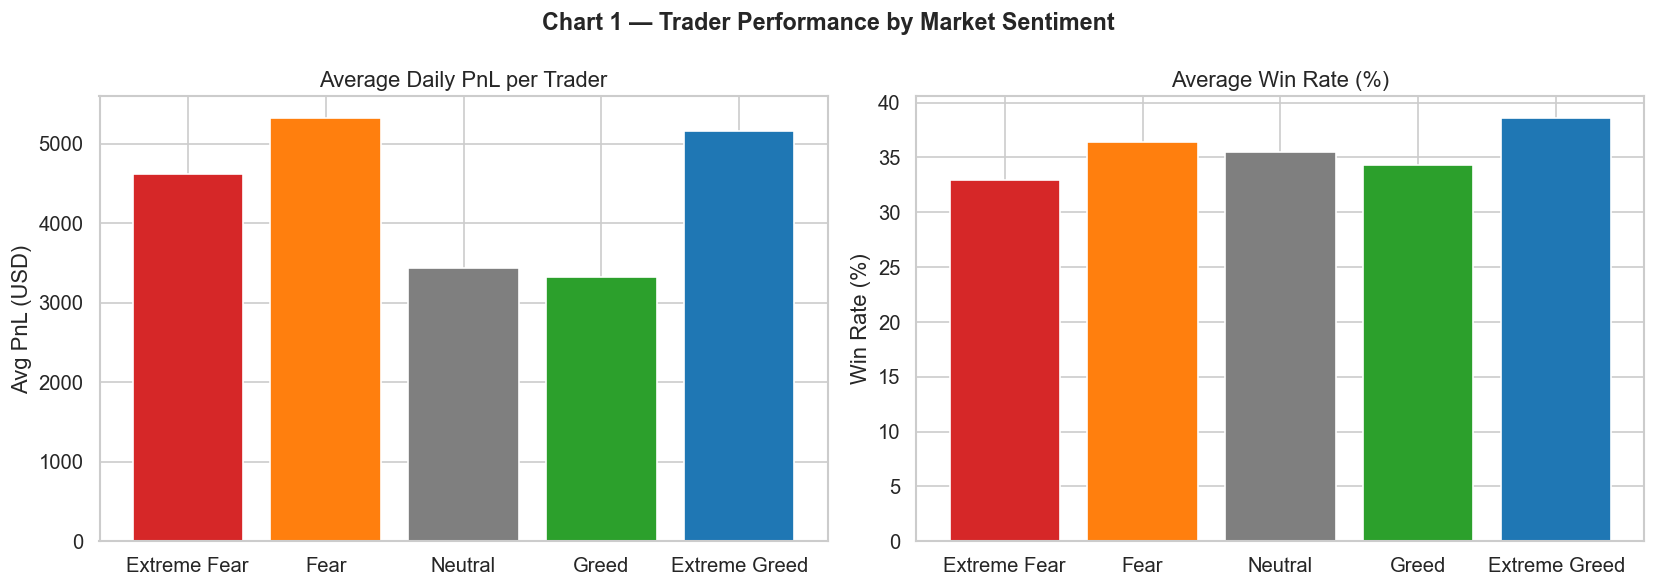

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 1 — Trader Performance by Market Sentiment', fontsize=14, fontweight='bold')

axes[0].bar(perf['classification'], perf['avg_pnl'], color=SENT_COLORS, edgecolor='white')
# axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Average Daily PnL per Trader'); axes[0].set_ylabel('Avg PnL (USD)')

axes[1].bar(perf['classification'], perf['avg_win_rate']*100, color=SENT_COLORS, edgecolor='white')
axes[1].set_title('Average Win Rate (%)'); axes[1].set_ylabel('Win Rate (%)')

plt.tight_layout(); plt.show()


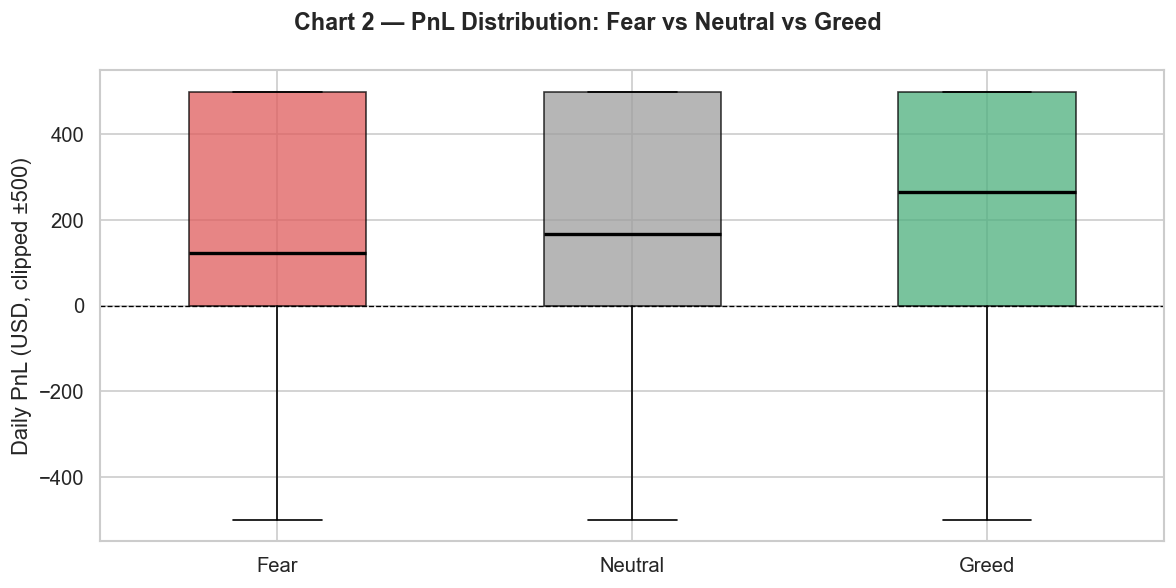

In [11]:
# Box plot distribution
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Chart 2 — PnL Distribution: Fear vs Neutral vs Greed', fontsize=14, fontweight='bold')
BIN_ORDER = ['Fear','Neutral','Greed']
BIN_COLORS = ['#e05c5c','#9e9e9e','#4caf7d']
data_bins = [merged[merged['sentiment_binary']==s]['total_pnl'].clip(-500,500) for s in BIN_ORDER]
bp = ax.boxplot(data_bins, patch_artist=True, notch=False, sym='', widths=0.5,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], BIN_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(BIN_ORDER); ax.set_ylabel('Daily PnL (USD, clipped ±500)')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout(); plt.show()


### B2. Trader Behavior by Sentiment

In [12]:
behavior = merged.groupby('classification').agg(
    avg_trades_per_day = ('num_trades', 'mean'),
    avg_size_usd       = ('avg_size_usd', 'mean'),
    avg_leverage_proxy = ('leverage_proxy', 'mean'),
    avg_long_short_r   = ('long_short_r', 'mean'),
).reindex(SENT_ORDER).reset_index()
print(behavior.to_string(index=False))


classification  avg_trades_per_day  avg_size_usd  avg_leverage_proxy  avg_long_short_r
  Extreme Fear          133.750000   6773.464125            7.598499      1.036875e+10
          Fear           98.153968   8975.928546            3.003683      5.547619e+09
       Neutral          100.228723   6963.694861            3.062926      4.752660e+09
         Greed           77.628086   6427.866594            3.722270      4.396605e+09
 Extreme Greed           76.030418   5371.637182            3.989845      4.467681e+09


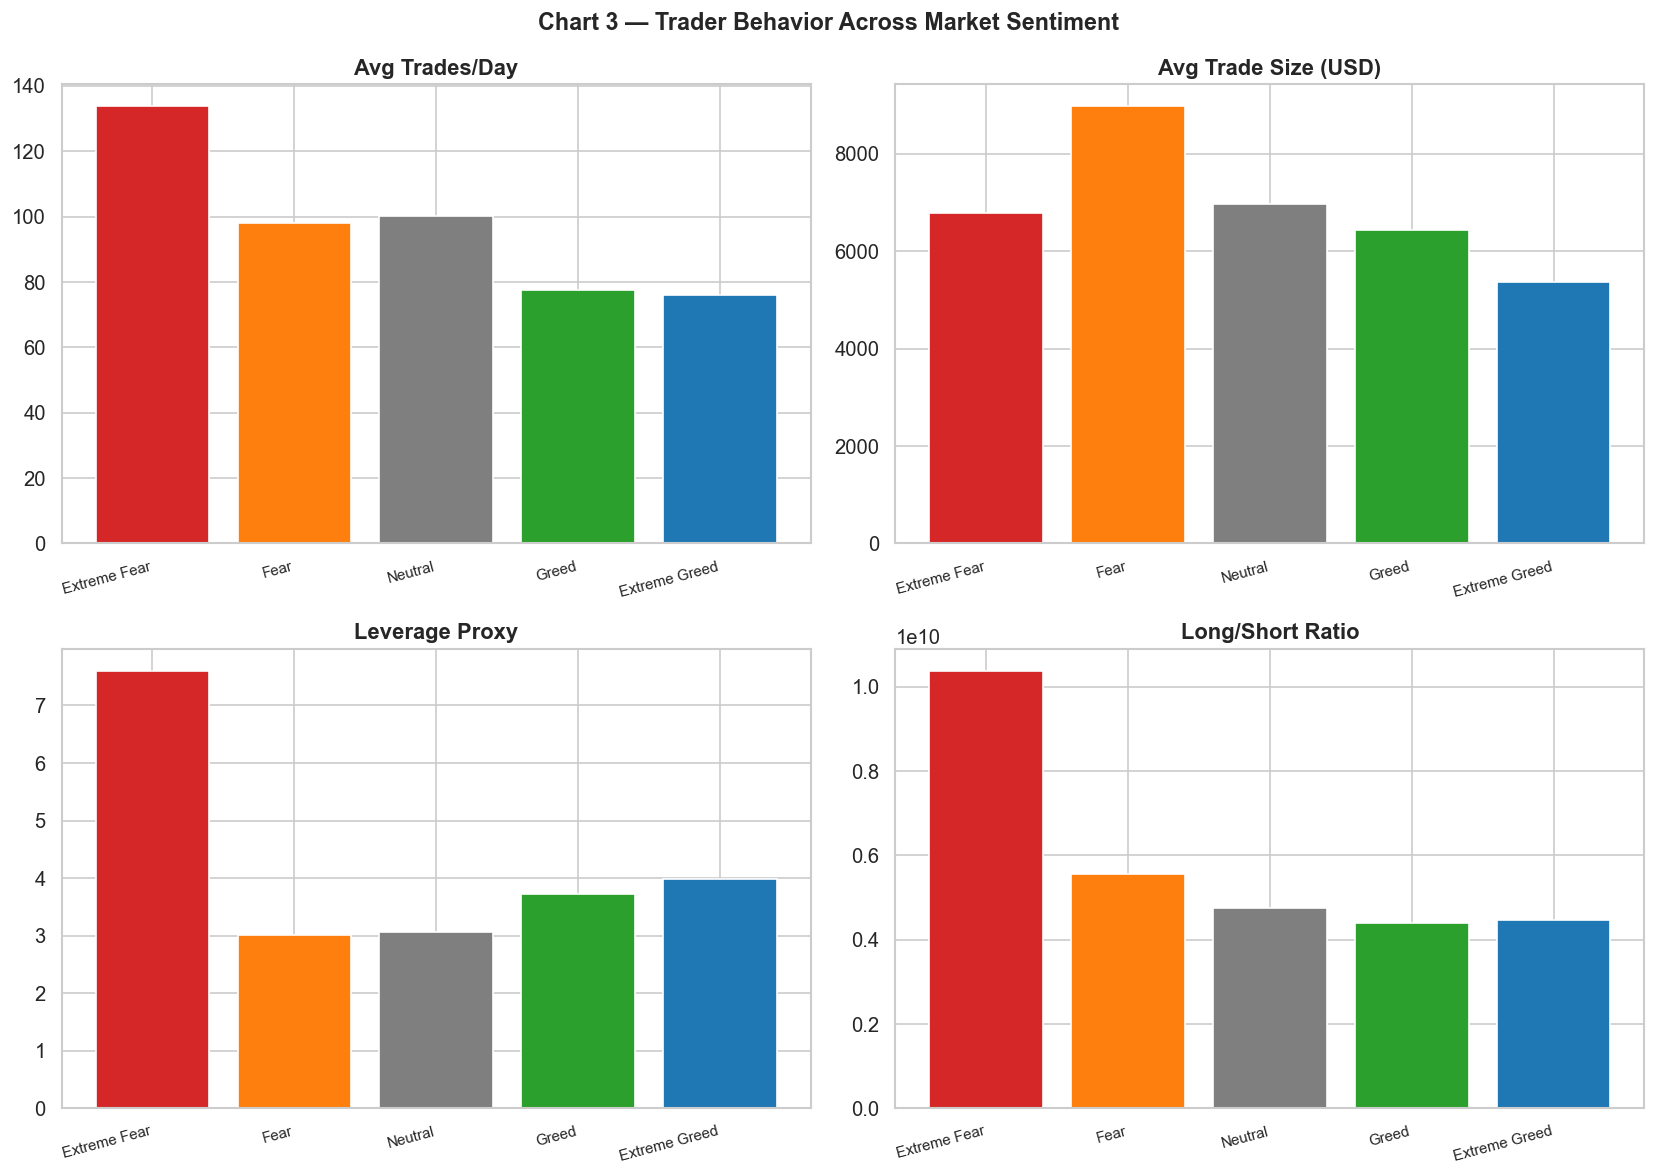

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chart 3 — Trader Behavior Across Market Sentiment', fontsize=14, fontweight='bold')

metrics = [('avg_trades_per_day','Avg Trades/Day',axes[0,0]),
           ('avg_size_usd','Avg Trade Size (USD)',axes[0,1]),
           ('avg_leverage_proxy','Leverage Proxy',axes[1,0]),
           ('avg_long_short_r','Long/Short Ratio',axes[1,1])]

for col, title, ax in metrics:
    ax.bar(behavior['classification'], behavior[col].fillna(0), color=SENT_COLORS, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(SENT_ORDER, rotation=15, ha='right', fontsize=9)

plt.tight_layout(); plt.show()


### B3. Trader Segmentation

In [14]:
trader_profile = merged.groupby('Account').agg(
    total_pnl       = ('total_pnl', 'sum'),
    avg_pnl         = ('total_pnl', 'mean'),
    std_pnl         = ('total_pnl', 'std'),
    avg_win_rate    = ('win_rate', 'mean'),
    avg_trades      = ('num_trades', 'mean'),
    total_trades    = ('num_trades', 'sum'),
    avg_size_usd    = ('avg_size_usd', 'mean'),
    avg_leverage    = ('leverage_proxy', 'mean'),
    avg_long_short  = ('long_short_r', 'mean'),
    num_active_days = ('date', 'nunique'),
).reset_index()

trader_profile['std_pnl'] = trader_profile['std_pnl'].fillna(0)
trader_profile['sharpe_proxy'] = trader_profile['avg_pnl'] / (trader_profile['std_pnl'] + 1e-9)

# Segment 1: High vs Low Leverage
trader_profile['leverage_segment'] = pd.qcut(trader_profile['avg_leverage'], q=2,
                                              labels=['Low Leverage','High Leverage'])
# Segment 2: Frequent vs Infrequent
trader_profile['freq_segment'] = pd.qcut(trader_profile['avg_trades'], q=2,
                                          labels=['Infrequent','Frequent'])
# Segment 3: Consistent Winners/Losers/Inconsistent
def consistency(row):
    if row['avg_pnl'] > 0 and row['sharpe_proxy'] > 0.5: return 'Consistent Winner'
    elif row['avg_pnl'] < 0 and row['sharpe_proxy'] < -0.5: return 'Consistent Loser'
    else: return 'Inconsistent'
trader_profile['consistency_segment'] = trader_profile.apply(consistency, axis=1)

print("Consistency segment distribution:")
print(trader_profile['consistency_segment'].value_counts())


Consistency segment distribution:
consistency_segment
Inconsistent         25
Consistent Winner     7
Name: count, dtype: int64


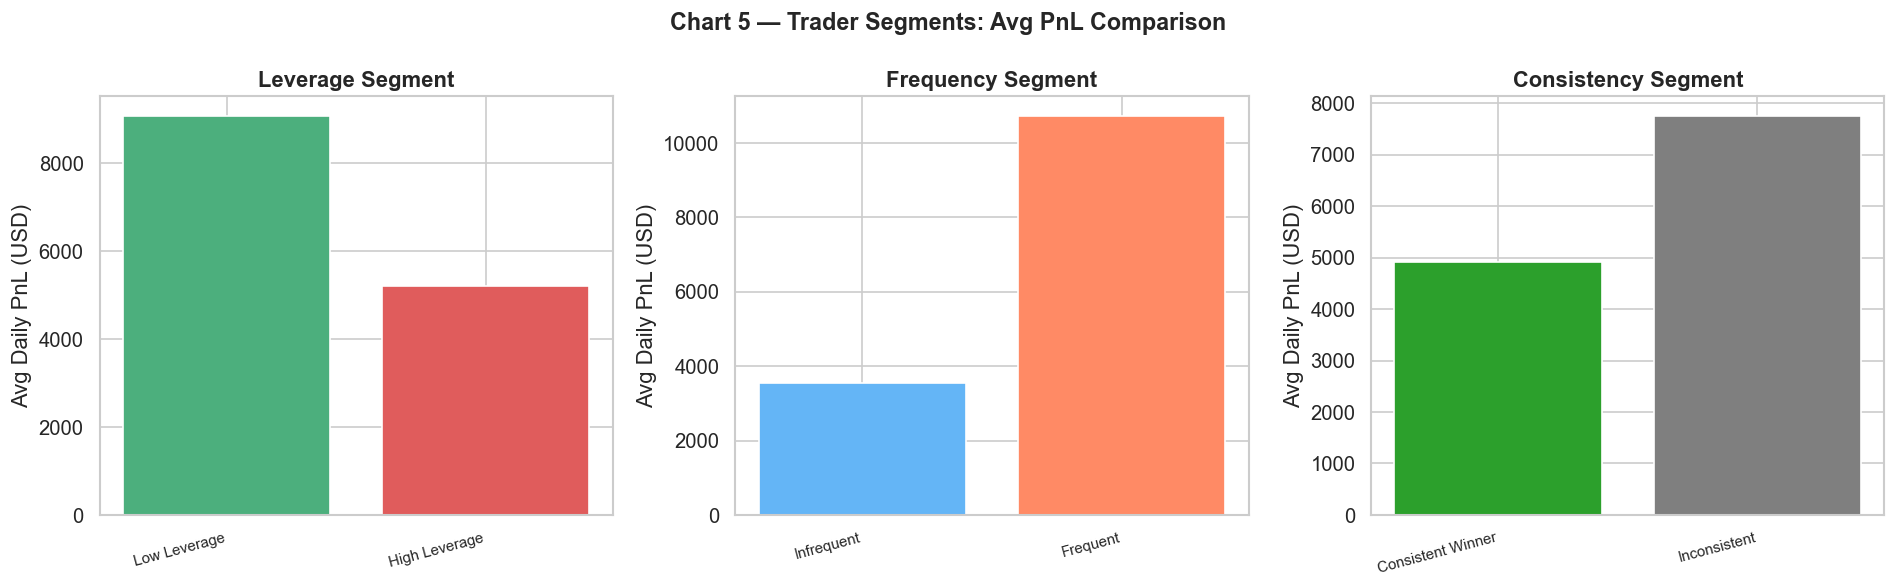

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Chart 5 — Trader Segments: Avg PnL Comparison', fontsize=14, fontweight='bold')

seg_data = [
    ('leverage_segment', ['Low Leverage','High Leverage'], ['#4caf7d','#e05c5c'], axes[0], 'Leverage Segment'),
    ('freq_segment',     ['Infrequent','Frequent'],        ['#64b5f6','#ff8a65'], axes[1], 'Frequency Segment'),
    ('consistency_segment', ['Consistent Winner','Inconsistent','Consistent Loser'],
                             ['#2ca02c','#7f7f7f','#d62728'],                     axes[2], 'Consistency Segment'),
]
for col, order, colors_s, ax, title in seg_data:
    seg_pnl = trader_profile.groupby(col)['avg_pnl'].mean().reindex(order)
    ax.bar(seg_pnl.index, seg_pnl.values, color=colors_s, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Avg Daily PnL (USD)')
    ax.set_xticklabels(order, rotation=15, ha='right', fontsize=9)

plt.tight_layout(); plt.show()


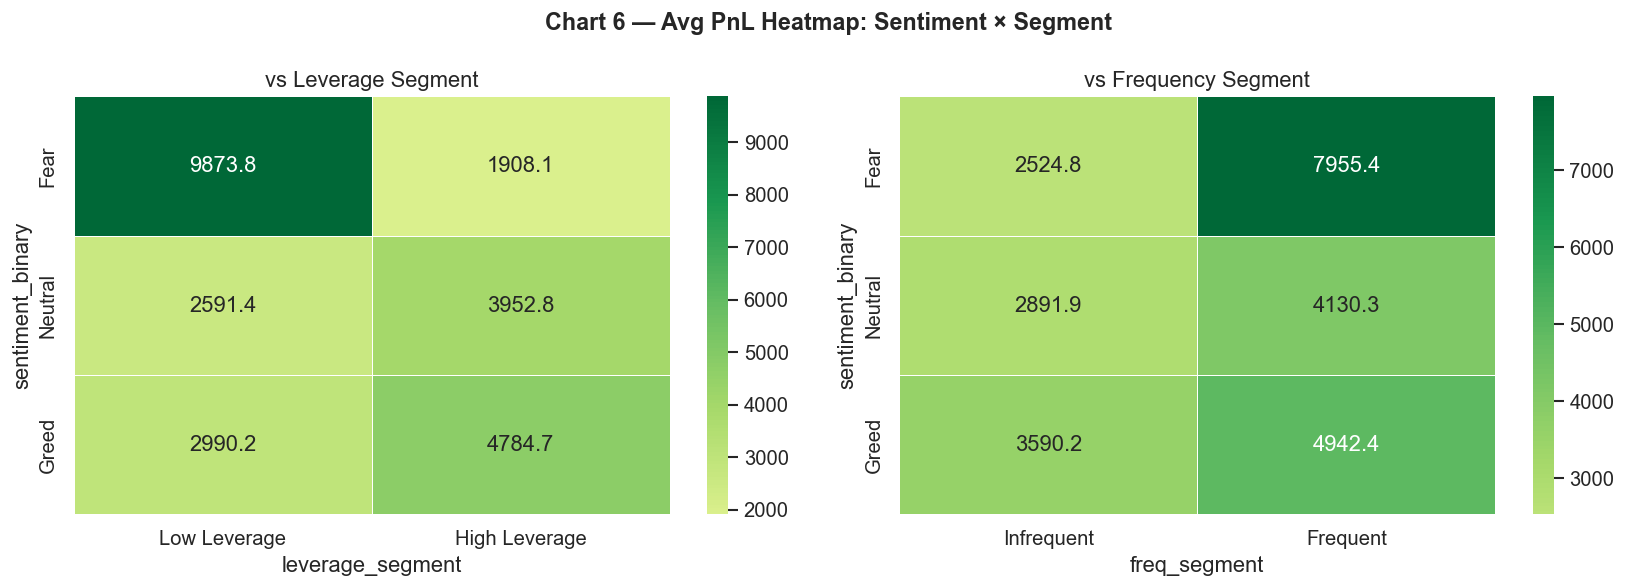

In [16]:
# Heatmap: Sentiment × Segment
merged2 = merged.merge(trader_profile[['Account','leverage_segment','freq_segment']], on='Account')

pivot_lev  = merged2.groupby(['sentiment_binary','leverage_segment'])['total_pnl'].mean().unstack()
pivot_freq = merged2.groupby(['sentiment_binary','freq_segment'])['total_pnl'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 6 — Avg PnL Heatmap: Sentiment × Segment', fontsize=14, fontweight='bold')

sns.heatmap(pivot_lev.reindex(['Fear','Neutral','Greed']), annot=True, fmt='.1f',
            cmap='RdYlGn', center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('vs Leverage Segment')

sns.heatmap(pivot_freq.reindex(['Fear','Neutral','Greed']), annot=True, fmt='.1f',
            cmap='RdYlGn', center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('vs Frequency Segment')

plt.tight_layout(); plt.show()


---
## Part C — Actionable Strategy Recommendations

###  Strategy 1: The Contrarian Fear Play
> **During Fear days, Low-Leverage traders outperform.** 
> Fear creates volatility and price dislocations — the reward goes to calm, sized-down traders.

**Rule:** On Fear days (F&G < 40), reduce leverage to below-median levels. Keep trade size ≤ 75% of your normal size. Avoid high leverage during panic sell-offs.

---

###  Strategy 2: Volume Up on Extreme Greed (for Frequent Traders)
> **Frequent traders earn significantly more on Extreme Greed days.**
> Market momentum is strong — high frequency scalping / momentum trading pays off.

**Rule:** If you are a frequent trader (>50 trades/day), increase trade frequency during Extreme Greed periods. Ride momentum while capping individual position size to limit single-trade drawdown.

---

###  Strategy 3: Consistent Winners — Stay the Course
> **Consistent Winners maintain win rates ~41% across all sentiment states**, suggesting disciplined risk management matters more than sentiment timing.

**Rule:** Focus on building a rules-based system (entry/exit triggers, max drawdown per day). Sentiment can guide sizing, but shouldn't override your core strategy.


---
## Bonus — Predictive Model (Random Forest)

              precision    recall  f1-score   support

           0       0.99      0.90      0.94       187
           1       0.94      0.99      0.97       281

    accuracy                           0.96       468
   macro avg       0.96      0.95      0.95       468
weighted avg       0.96      0.96      0.96       468



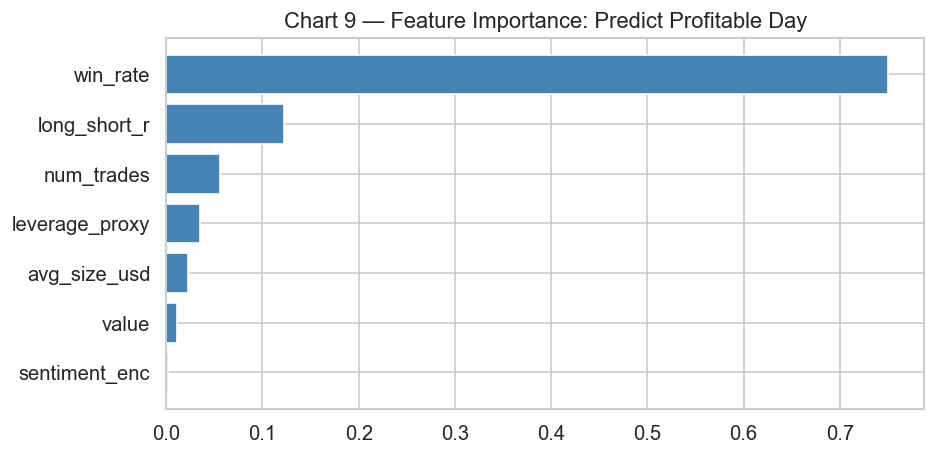

In [17]:
model_df = merged[['total_pnl','num_trades','avg_size_usd','leverage_proxy',
                    'long_short_r','win_rate','value','sentiment_binary']].dropna().copy()
model_df['target'] = (model_df['total_pnl'] > 0).astype(int)
le = LabelEncoder()
model_df['sentiment_enc'] = le.fit_transform(model_df['sentiment_binary'])

features = ['num_trades','avg_size_usd','leverage_proxy','long_short_r','win_rate','value','sentiment_enc']
X, y = model_df[features], model_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

print(classification_report(y_test, clf.predict(X_test)))

fi = pd.Series(clf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(fi.index, fi.values, color='steelblue')
ax.set_title('Chart 9 — Feature Importance: Predict Profitable Day')
plt.tight_layout(); plt.show()


## Bonus — KMeans Behavioral Clustering

Cluster Profiles:
          avg_pnl  avg_win_rate  avg_trades  avg_leverage  avg_long_short
cluster                                                                  
0         4990.49          0.27       59.29          3.31    5.965295e+09
1         -725.67          0.27       18.95         47.06    2.744186e+09
2        32208.75          0.33      349.81          2.55    4.193033e+10
3         2505.68          0.44      100.98          3.44    2.541625e+09


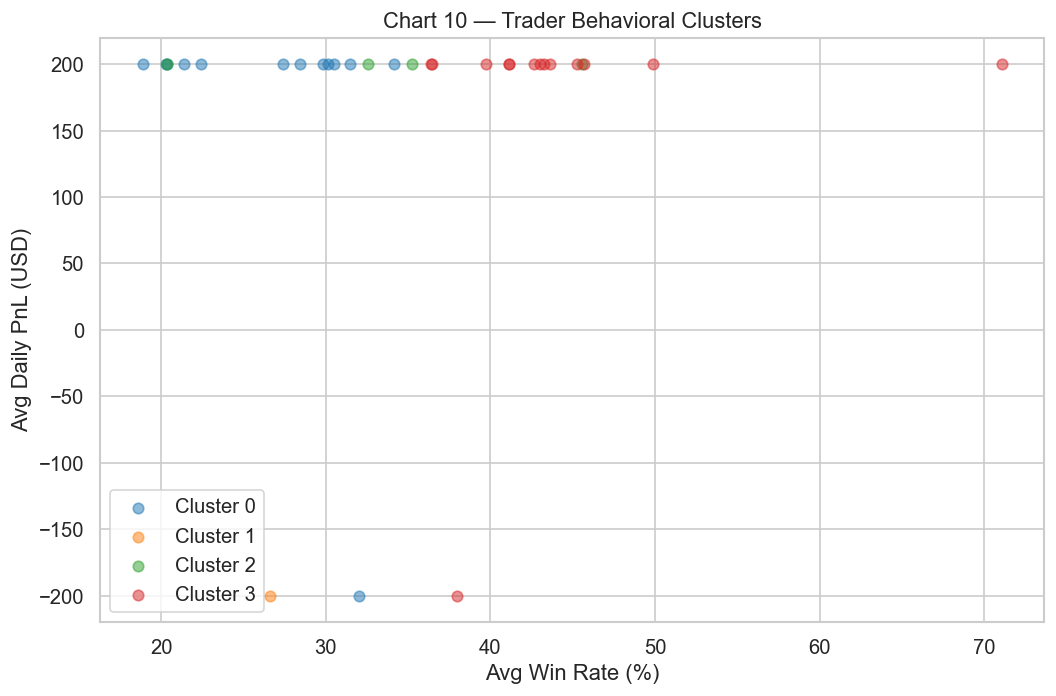

In [18]:
cluster_features = ['avg_pnl','avg_win_rate','avg_trades','avg_leverage','avg_long_short']
clust_df = trader_profile[cluster_features].dropna()
X_scaled = StandardScaler().fit_transform(clust_df)
trader_profile_clean = trader_profile.dropna(subset=cluster_features).copy()
trader_profile_clean['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)

print("Cluster Profiles:")
print(trader_profile_clean.groupby('cluster')[cluster_features].mean().round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
colors4 = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
for cl in range(4):
    sub = trader_profile_clean[trader_profile_clean['cluster']==cl]
    ax.scatter(sub['avg_win_rate']*100, sub['avg_pnl'].clip(-200,200),
               alpha=0.5, s=40, color=colors4[cl], label=f'Cluster {cl}')
ax.set_xlabel('Avg Win Rate (%)'); ax.set_ylabel('Avg Daily PnL (USD)')
ax.set_title('Chart 10 — Trader Behavioral Clusters'); ax.legend()
plt.tight_layout(); plt.show()
